# Experimentos Exploratorios

**Propósito:** Este notebook contiene experimentos adicionales para analizar decisiones de diseño y validar el pipeline principal.

**Experimentos incluidos:**
1. **Baseline de PCA:** Comparar embeddings del VAE vs PCA para justificar la elección de arquitectura no lineal.
2. **Entrenamiento solo en CN:** Entrenar VAE + XGBoost únicamente en controles sanos, evaluar brain-age gap en AD/FTD.
3. **FC crudo + T1w (sin VAE):** Evaluar si XGBoost con features crudos de FC (6670) + T1w (116) rinde peor que con features comprimidos por VAE (64 + 116), justificando la reducción de dimensionalidad.

**Nota:** Este notebook NO modifica el pipeline principal. Todos los resultados se guardan en `Outputs/experiments/`.

### Configuración del entorno

Resolución de la raíz del proyecto, imports de los módulos del pipeline y librerías externas necesarias para los experimentos (PCA, StandardScaler, etc.).

## Setup

### Imports del pipeline y configuración

Se importan los módulos de `src/`, se definen las rutas a los datos y se crea el directorio de salida para experimentos (`Outputs/experiments/`). `use_optuna=False` porque estos experimentos reutilizan los hiperparámetros ya optimizados en el pipeline principal.

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Resolve project root
_cwd = Path.cwd()
if (_cwd / "src").exists():
    ROOT = _cwd
elif (_cwd.parent / "src").exists():
    ROOT = _cwd.parent
else:
    raise RuntimeError(f"Cannot locate project root from {_cwd}")

REPO = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Code root:", ROOT)
print("Repo root:", REPO)

Code root: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Code
Repo root: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci


### Imports del pipeline y semilla global

Se cargan los módulos de `src/`, se configuran paths, y se crea el directorio de experimentos.

In [2]:
from src.config import Paths, ExperimentConfig
from src.utils_seed import set_global_seed
from src.cohort import build_final_cohort_df
from src.splits import make_holdout_split, make_kfold_splits, save_splits, load_splits
from src.data_io import load_fc_vectors_for_ids
from src.vae_train import train_vae_kfold, train_vae_final, load_vae_from_dir, load_history
from src.embeddings import encode_mu, save_embeddings, load_embeddings
from src.xgb_train import build_feats, clean_xy, train_xgb, eval_xgb
from src.metrics import regression_metrics
from src.figures import plot_pred_scatter

paths = Paths(
    excel_path=REPO / "Data" / "datos-redlat.xlsx",
    fc_folder=REPO / "Data" / "fc_mats",
    t1w_csv_path=REPO / "Data" / "Redlat_VGM_AAL_.csv",
    out_dir=REPO / "Outputs",
)

cfg = ExperimentConfig(
    seed=42,
    diagnoses_to_use=("CN", "AD", "FTD"),
    test_size=0.10,
    k_folds=5,
    fisher_z=True,
    reuse_artifacts=True,
    use_optuna=False,  # Experiments use existing best params
)

set_global_seed(cfg.seed)

# Create experiments output directory
EXP_DIR = paths.out_dir / "experiments"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experiments output: {EXP_DIR}")

2026-02-17 01:32:12.475327: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-17 01:32:12.514529: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Experiments output: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments


2026-02-17 01:32:13.597084: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Carga de Datos y Splits

Usamos la misma cohorte y splits que el pipeline principal para comparabilidad.

In [3]:
# Load cohort
cohort_df = build_final_cohort_df(
    paths.excel_path,
    paths.fc_folder,
    paths.t1w_csv_path,
    diagnoses_to_use=cfg.diagnoses_to_use,
)

print(f"Total cohort: N={len(cohort_df)}")
print(f"Diagnoses: {cohort_df['diagnosis'].value_counts().to_dict()}")
print(f"Age range: {cohort_df['age'].min():.1f} - {cohort_df['age'].max():.1f} years")

Total cohort: N=1245
Diagnoses: {'CN': 526, 'AD': 422, 'FTD': 297}
Age range: 18.0 - 98.0 years


### Carga de splits existentes

Se cargan las particiones holdout y K-Fold del pipeline principal para garantizar comparabilidad con los resultados de referencia.

In [4]:
# Load existing splits from main pipeline
splits_file = paths.out_dir / "splits" / f"splits_seed{cfg.seed}_test{cfg.test_size}.json"
with open(splits_file) as f:
    splits_data = json.load(f)

trainval_ids = splits_data['holdout']['trainval_ids']
test_ids = splits_data['holdout']['test_ids']
kfold_list = splits_data['folds']

print(f"Trainval: {len(trainval_ids)}, Test: {len(test_ids)}")
print(f"KFold: {len(kfold_list)} folds")

Trainval: 1120, Test: 125
KFold: 5 folds


### Carga de vectores FC

Se cargan todas las matrices FC vectorizadas (con Fisher z-transform) para la cohorte completa. La matriz resultante tiene forma *(sujetos, 6670)*: una fila por sujeto y 6670 columnas correspondientes al triángulo superior de la matriz de correlación 116×116 (cada columna es una correlación entre dos regiones AAL). A partir de los IDs de trainval y test se separan luego los subconjuntos correspondientes.

In [5]:
# Load FC vectors
X_all = load_fc_vectors_for_ids(
    paths.fc_folder,
    cohort_df["record_id"].tolist(),
    apply_fisher_z=cfg.fisher_z,
)

print(f"FC matrix: {X_all.shape}")

FC matrix: (1245, 6670)


---

## Experimento 1: Baseline de PCA

**Objetivo:** Comparar embeddings del VAE (64 dims) con PCA (64 componentes) para predecir edad.

**Hipótesis:** El VAE debería superar a PCA porque puede modelar relaciones no lineales en FC.

**Método:**
1. Particionar la matriz FC por los IDs de trainval y test (mismo split que el pipeline principal).
2. Estandarizar FC (scaler ajustado solo con trainval; a test se le aplica la misma transformación para evitar data leakage). Ajustar PCA con 64 componentes solo sobre trainval; proyectar test con las mismas componentes.
3. Entrenar XGBoost con PCA + T1w (mismos hiperparámetros que el mejor modelo) y comparar MAE, R², Pearson con VAE + T1w.

**Resultado esperado:** VAE > PCA (menor MAE, mayor R²).

**Partición train/test.**  
- **ID** = identificador del sujeto (ej. `AF025`). **Índice** = número de fila (0, 1, 2, …). La matriz `X_all` tiene una fila por sujeto en el mismo orden que la cohorte, pero el split guarda IDs, no posiciones.  
- Se construye un diccionario *ID → posición*: así sabemos "el sujeto AF025 está en la fila 42 de X_all". Con la lista de IDs de trainval se obtienen las posiciones (ej. [3, 7, 0, …]); `X_all[esas posiciones]` devuelve solo esas filas. Resultado: `X_trainval` (1120, 6670), `X_test` (125, 6670).

In [6]:
# Get indices for trainval and test
id_to_idx = {rec_id: i for i, rec_id in enumerate(cohort_df["record_id"])}
trainval_idx = [id_to_idx[rid] for rid in trainval_ids]
test_idx = [id_to_idx[rid] for rid in test_ids]

X_trainval = X_all[trainval_idx]
X_test = X_all[test_idx]

print(f"X_trainval: {X_trainval.shape}, X_test: {X_test.shape}")

X_trainval: (1120, 6670), X_test: (125, 6670)


### Estandarización y PCA

**Estandarización:** Se aplica `StandardScaler` para que cada columna tenga media 0 y desviación estándar 1 en trainval. Así PCA no queda dominado por columnas con escala mayor. El scaler se ajusta solo con trainval (`fit_transform`); a test se le aplica la misma transformación (`transform`) para evitar filtrar información del test.

**PCA:** Se ajusta con 64 componentes (misma dimensión que el VAE) solo sobre trainval (`fit_transform`); test se proyecta con las mismas componentes (`transform`). Salida: vectores (1120, 64) y (125, 64) que se concatenan con T1w para XGBoost.

In [11]:
# Standardize FC (PCA expects standardized inputs)
scaler = StandardScaler()
X_trainval_scaled = scaler.fit_transform(X_trainval)
X_test_scaled = scaler.transform(X_test)

# Fit PCA (64 components to match VAE latent_dim)
pca = PCA(n_components=64, random_state=cfg.seed)
Z_pca_tr = pca.fit_transform(X_trainval_scaled)
Z_pca_te = pca.transform(X_test_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA embeddings: train {Z_pca_tr.shape}, test {Z_pca_te.shape}")
print(f"Explained variance: {explained_var:.3f} ({explained_var*100:.1f}%)")

PCA embeddings: train (1120, 64), test (125, 64)
Explained variance: 0.630 (63.0%)


### Carga de embeddings VAE del pipeline principal

Se cargan los embeddings μ ya generados en `main.ipynb` para compararlos directamente con los embeddings PCA.

In [12]:
# Load VAE embeddings from main pipeline for comparison
emb_dir = paths.out_dir / "embeddings"
z_tr_ids, Z_vae_tr = load_embeddings(emb_dir / "mu_trainval")
z_te_ids, Z_vae_te = load_embeddings(emb_dir / "mu_test")

# Verify alignment
assert z_tr_ids == trainval_ids, "VAE trainval IDs mismatch"
assert z_te_ids == test_ids, "VAE test IDs mismatch"

print(f"VAE embeddings: train {Z_vae_tr.shape}, test {Z_vae_te.shape}")

VAE embeddings: train (1120, 64), test (125, 64)


### Función auxiliar y extracción de features

Se define `get_data_for_ids()` para extraer edad, sexo, diagnóstico y T1w dado un conjunto de IDs, y se obtienen las variables para trainval y test.

In [13]:
# Helper to get y, sex, diagnosis, T1w for given IDs
def get_data_for_ids(ids):
    df_sub = cohort_df[cohort_df["record_id"].isin(ids)].set_index("record_id").loc[ids].reset_index()
    y = df_sub["age"].values
    sex = (df_sub["sex"] == "M").astype(float).values
    diag = df_sub["diagnosis"].map({"CN": 0, "AD": 1, "FTD": 2}).values
    T1 = df_sub[[c for c in df_sub.columns if c.startswith("t1_")]].values
    return y, sex, diag, T1

y_tr, sex_tr, diag_tr, T1_tr = get_data_for_ids(trainval_ids)
y_te, sex_te, diag_te, T1_te = get_data_for_ids(test_ids)

print(f"y_tr: {y_tr.shape}, T1_tr: {T1_tr.shape}")

y_tr: (1120,), T1_tr: (1120, 116)


### Carga de hiperparámetros óptimos de XGBoost

Se cargan los mejores hiperparámetros de XGBoost encontrados en el pipeline principal para usarlos en ambas comparaciones (PCA y VAE).

In [14]:
# Load best XGBoost params from main pipeline
xgb_params_path = paths.out_dir / "optuna" / "xgb_best_cv.json"
with open(xgb_params_path) as f:
    best_xgb_params = json.load(f)["best_params"]

print("Best XGBoost params loaded:", best_xgb_params)

Best XGBoost params loaded: {'n_estimators': 2103, 'max_depth': 6, 'learning_rate': 0.011042092255313062, 'subsample': 0.5021328242984182, 'colsample_bytree': 0.9505971249574193, 'reg_alpha': 0.0013554585093299317, 'reg_lambda': 7.0841939500925095, 'min_child_weight': 1.1415352944950146, 'gamma': 0.6749458207517294, 'tree_method': 'hist', 'random_state': 42, 'eval_metric': 'mae'}


### Entrenamiento y evaluación: PCA vs VAE

Se entrenan dos modelos XGBoost con los mismos hiperparámetros óptimos: uno con features PCA + T1w y otro con features VAE + T1w. La comparación se realiza sobre el mismo conjunto de test para una evaluación justa.

In [15]:
# Train XGBoost with PCA + T1w (best ablation config from main pipeline)
X_pca_tr = build_feats(Z=Z_pca_tr, T1=T1_tr)
X_pca_te = build_feats(Z=Z_pca_te, T1=T1_te)

X_pca_tr_clean, y_tr_clean = clean_xy(X_pca_tr, y_tr)
X_pca_te_clean, y_te_clean = clean_xy(X_pca_te, y_te)

model_pca = train_xgb(X_pca_tr_clean, y_tr_clean, best_xgb_params)
y_pred_pca = model_pca.predict(X_pca_te_clean)
metrics_pca = regression_metrics(y_te_clean, y_pred_pca)

print("\n=== PCA + T1w Results ===")
print(f"MAE:  {metrics_pca['MAE']:.2f} years")
print(f"RMSE: {metrics_pca['RMSE']:.2f} years")
print(f"R²:   {metrics_pca['R2']:.3f}")
print(f"Pearson: {metrics_pca['Pearson']:.3f}")


=== PCA + T1w Results ===
MAE:  5.61 years
RMSE: 7.08 years
R²:   0.431
Pearson: 0.661


### Entrenamiento de XGBoost con features VAE + T1w

Mismo procedimiento que el caso PCA, pero utilizando los embeddings del VAE como representación de la conectividad funcional.

In [16]:
# Train XGBoost with VAE + T1w (for comparison)
X_vae_tr = build_feats(Z=Z_vae_tr, T1=T1_tr)
X_vae_te = build_feats(Z=Z_vae_te, T1=T1_te)

X_vae_tr_clean, _ = clean_xy(X_vae_tr, y_tr)
X_vae_te_clean, _ = clean_xy(X_vae_te, y_te)

model_vae = train_xgb(X_vae_tr_clean, y_tr_clean, best_xgb_params)
y_pred_vae = model_vae.predict(X_vae_te_clean)
metrics_vae = regression_metrics(y_te_clean, y_pred_vae)

print("\n=== VAE + T1w Results ===")
print(f"MAE:  {metrics_vae['MAE']:.2f} years")
print(f"RMSE: {metrics_vae['RMSE']:.2f} years")
print(f"R²:   {metrics_vae['R2']:.3f}")
print(f"Pearson: {metrics_vae['Pearson']:.3f}")


=== VAE + T1w Results ===
MAE:  5.62 years
RMSE: 7.20 years
R²:   0.411
Pearson: 0.644


### Comparación de resultados y guardado

Se imprime la tabla comparativa PCA vs VAE y se guardan los resultados en JSON para referencia futura.

In [17]:
# Comparison table
print("\n" + "="*60)
print("EXPERIMENT 1: PCA vs VAE Baseline Comparison")
print("="*60)
print(f"{'Method':<15} | {'MAE':>6} | {'RMSE':>6} | {'R²':>6} | {'Pearson':>7}")
print("-"*60)
print(f"{'PCA (64 dims)':<15} | {metrics_pca['MAE']:6.2f} | {metrics_pca['RMSE']:6.2f} | {metrics_pca['R2']:6.3f} | {metrics_pca['Pearson']:7.3f}")
print(f"{'VAE (64 dims)':<15} | {metrics_vae['MAE']:6.2f} | {metrics_vae['RMSE']:6.2f} | {metrics_vae['R2']:6.3f} | {metrics_vae['Pearson']:7.3f}")
print("-"*60)
mae_diff = metrics_pca['MAE'] - metrics_vae['MAE']
r2_diff = metrics_vae['R2'] - metrics_pca['R2']
print(f"VAE improvement: {-mae_diff:+.2f} years MAE, {r2_diff:+.3f} R²")
print("="*60)

# Save results
exp1_results = {
    "pca": metrics_pca,
    "vae": metrics_vae,
    "vae_improvement": {
        "mae_diff": float(-mae_diff),
        "r2_diff": float(r2_diff),
    },
    "pca_explained_variance": float(explained_var),
}

exp1_path = EXP_DIR / "exp1_pca_vs_vae.json"
with open(exp1_path, "w") as f:
    json.dump(exp1_results, f, indent=2)

print(f"\nResults saved: {exp1_path}")


EXPERIMENT 1: PCA vs VAE Baseline Comparison
Method          |    MAE |   RMSE |     R² | Pearson
------------------------------------------------------------
PCA (64 dims)   |   5.61 |   7.08 |  0.431 |   0.661
VAE (64 dims)   |   5.62 |   7.20 |  0.411 |   0.644
------------------------------------------------------------
VAE improvement: +0.01 years MAE, -0.020 R²

Results saved: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/exp1_pca_vs_vae.json


### Tabla comparativa y guardado de resultados

Resumen final del Experimento 1: se comparan MAE, RMSE, R² y Pearson entre PCA y VAE, y se persisten los resultados en JSON.

---

## Experimento 2: Entrenamiento Solo en CN (Controles Sanos)

**Objetivo:** Evaluar si entrenar solo en sujetos sanos (CN) mejora la estimación de edad y permite medir el "brain age gap" en pacientes con AD/FTD.

**Hipótesis:** El modelo CN-only debería:
- Tener MAE similar o mejor en sujetos CN test
- Mostrar brain age gap positivo (edad predicha > edad real) en AD/FTD

**Método:**
1. Filtrar trainval para incluir solo CN
2. Entrenar VAE en FC de CN (con hiperparámetros óptimos del pipeline principal)
3. Entrenar XGBoost en CN (con hiperparámetros óptimos)
4. Evaluar en:
   - CN test (normal aging error)
   - AD test (brain age gap)
   - FTD test (brain age gap)

**Nota:** Este experimento puede tomar ~1-2 horas (entrenar VAE + XGBoost).

In [ ]:
# --------------------------------------------------------------------------
# FIX: use CN subjects from the MAIN trainval split (not an independent split)
# to avoid data leakage between training and the main test set.
# --------------------------------------------------------------------------
cn_all_ids = set(cohort_df.loc[cohort_df["diagnosis"] == "CN", "record_id"])
cn_trainval_ids = sorted([rid for rid in trainval_ids if rid in cn_all_ids])
cn_test_ids     = sorted([rid for rid in test_ids     if rid in cn_all_ids])

cn_df = cohort_df[cohort_df["diagnosis"] == "CN"].copy()
print(f"CN cohort (total): N={len(cn_df)}")
print(f"Age range: {cn_df['age'].min():.1f} - {cn_df['age'].max():.1f} years")
print(f"Sex distribution: {cn_df['sex'].value_counts().to_dict()}")
print(f"CN trainval (from main split): {len(cn_trainval_ids)}")
print(f"CN test     (from main split): {len(cn_test_ids)}")

cn_kfold = make_kfold_splits(
    cn_trainval_ids,
    seed=cfg.seed,
    k=cfg.k_folds,
)
print(f"CN KFold: {len(cn_kfold)} folds")

CN cohort: N=526
Age range: 18.0 - 92.0 years
Sex distribution: {'Male': 348, 'Female': 178}
CN trainval: 473, CN test: 53
CN KFold: 5 folds


### Guardado de splits CN

Se persisten las particiones holdout y K-Fold de la sub-cohorte CN para reproducibilidad.

In [19]:
# Save CN splits (using main holdout, only CN subjects)
cn_splits_dir = EXP_DIR / "exp2_cn_only" / "splits"
cn_splits_dir.mkdir(parents=True, exist_ok=True)

cn_splits = {
    "cn_trainval_ids": cn_trainval_ids,
    "cn_test_ids": cn_test_ids,
    "folds": cn_kfold,
}
save_splits(cn_splits_dir / "cn_splits.json", cn_splits)

print(f"CN splits saved: {cn_splits_dir}")

CN splits saved: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/exp2_cn_only/splits


### Guardado de splits CN y carga de datos FC

Se guardan las particiones de la sub-cohorte CN para reproducibilidad y se cargan sus matrices FC vectorizadas.

In [20]:
# Get FC for CN subjects
cn_trainval_idx = [id_to_idx[rid] for rid in cn_trainval_ids if rid in id_to_idx]
cn_test_idx = [id_to_idx[rid] for rid in cn_test_ids if rid in id_to_idx]

X_cn_trainval = X_all[cn_trainval_idx]
X_cn_test = X_all[cn_test_idx]

print(f"X_cn_trainval: {X_cn_trainval.shape}, X_cn_test: {X_cn_test.shape}")

X_cn_trainval: (473, 6670), X_cn_test: (53, 6670)


### Carga de datos FC para sujetos CN

Se seleccionan las matrices FC correspondientes a los sujetos CN de trainval y test.

In [21]:
# Load best VAE hyperparameters from main pipeline
vae_params_path = paths.out_dir / "vae" / "vae_final_trainval_optuna" / "hparams.json"
with open(vae_params_path) as f:
    best_vae_params = json.load(f)

print("Best VAE params loaded:")
for k, v in best_vae_params.items():
    print(f"  {k}: {v}")

Best VAE params loaded:
  input_dim: 6670
  hidden_dims: [512]
  latent_dim: 64
  beta_target: 0.056663247229966504
  warmup_ep: 73
  l2_reg: 2.897389671945472e-07
  lr: 0.001892443497356961
  recon_kind: mae
  drop_rate: 0.036861053246000725
  activation: elu
  norm_kind: layernorm
  max_epochs: 96
  batch_size: 64
  clipnorm: 1.0
  seed: 42


### Carga de hiperparámetros del VAE

Se reutilizan los mejores hiperparámetros del VAE encontrados en el pipeline principal (misma arquitectura, mismo β, mismo learning rate).

### Entrenamiento del VAE sobre la cohorte CN

Se entrena el β-VAE desde cero utilizando únicamente las matrices FC de los sujetos CN del trainval (N=473), con los mismos hiperparámetros óptimos encontrados en el pipeline principal. El objetivo es obtener representaciones latentes que capturen el envejecimiento saludable sin la influencia de patologías.

In [22]:
# Train VAE on CN trainval
# Note: This will take ~30-60 minutes depending on your hardware

cn_vae_dir = EXP_DIR / "exp2_cn_only" / "vae"
cn_vae_dir.mkdir(parents=True, exist_ok=True)

print("Training VAE on CN subjects...")
print(f"This may take 30-60 minutes. Output dir: {cn_vae_dir}")

cn_vae, cn_vae_history = train_vae_final(
    X_cn_trainval,
    out_dir=cn_vae_dir,
    epochs=96,  # Use same as main pipeline
    seed=cfg.seed,
    **{k: best_vae_params[k] for k in [
        "hidden_dims", "latent_dim", "beta_target", "warmup_ep", "l2_reg", "lr",
        "recon_kind", "drop_rate", "activation", "norm_kind", "batch_size", "clipnorm",
    ]},
)

print(f"\nCN VAE training complete. Final loss: {cn_vae_history['loss'][-1]:.2f}")

Training VAE on CN subjects...
This may take 30-60 minutes. Output dir: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/exp2_cn_only/vae
Epoch 1/96


2026-02-17 01:33:16.878656: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - kl_loss: 942.9709 - loss: 1976.3165 - recon_loss: 1976.3165 - learning_rate: 0.0019
Epoch 2/96
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - kl_loss: 3094.9829 - loss: 1480.5015 - recon_loss: 1478.0992 - learning_rate: 0.0019
Epoch 3/96
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - kl_loss: 947.4072 - loss: 1350.0985 - recon_loss: 1348.6278 - learning_rate: 0.0019
Epoch 4/96
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - kl_loss: 745.1091 - loss: 1282.3416 - recon_loss: 1280.6064 - learning_rate: 0.0019
Epoch 5/96
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - kl_loss: 736.0675 - loss: 1243.0221 - recon_loss: 1240.7368 - learning_rate: 0.0019
Epoch 6/96
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - kl_loss: 659.0363 - loss: 1212.4802 - recon_loss: 1209.9225 - learning_rate: 0.0019
Epoch 7/96
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - kl_loss: 628.4994 - loss: 1189.5255 - recon_loss: 1186.5984 - learning_rate: 0.0019
Epoch 8/96
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - kl_loss: 626.9

### Extracción de embeddings

Se extraen los embeddings μ del VAE CN-only para los sujetos de trainval CN y para todos los sujetos de test (CN, AD, FTD).

In [23]:
# Extract embeddings for CN trainval and all test subjects (CN, AD, FTD)

# CN trainval embeddings
Z_cn_tr = encode_mu(cn_vae.encoder, X_cn_trainval)

# All test subjects (to evaluate brain age gap in AD/FTD)
X_all_test = X_all[test_idx]
Z_all_test = encode_mu(cn_vae.encoder, X_all_test)

print(f"CN trainval embeddings: {Z_cn_tr.shape}")
print(f"All test embeddings: {Z_all_test.shape}")

# Save embeddings
cn_emb_dir = EXP_DIR / "exp2_cn_only" / "embeddings"
cn_emb_dir.mkdir(parents=True, exist_ok=True)

save_embeddings(cn_emb_dir / "Z_cn_trainval", cn_trainval_ids, Z_cn_tr)
save_embeddings(cn_emb_dir / "Z_test", test_ids, Z_all_test)

print(f"Embeddings saved: {cn_emb_dir}")

CN trainval embeddings: (473, 64)
All test embeddings: (125, 64)
Embeddings saved: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/exp2_cn_only/embeddings


In [24]:
# Get y, T1w for CN trainval
y_cn_tr, _, _, T1_cn_tr = get_data_for_ids(cn_trainval_ids)

# Get y, T1w, diagnosis for all test subjects
y_all_te, _, diag_all_te, T1_all_te = get_data_for_ids(test_ids)

print(f"CN trainval: y {y_cn_tr.shape}, T1 {T1_cn_tr.shape}")
print(f"All test: y {y_all_te.shape}, T1 {T1_all_te.shape}")

CN trainval: y (473,), T1 (473, 116)
All test: y (125,), T1 (125, 116)


### Features y entrenamiento de XGBoost CN-only

Se obtienen las features T1w para los sujetos CN de trainval y se entrena XGBoost con VAE + T1w (mismos hiperparámetros que el pipeline principal).

### Evaluación por grupo diagnóstico y brain-age gap

Se evalúa el modelo CN-only sobre todos los sujetos del test set, separados por diagnóstico (CN, AD, FTD). Para cada grupo se calculan las métricas de regresión y el brain-age gap medio (edad predicha - edad real). Se espera que AD y FTD muestren un gap positivo, indicando envejecimiento cerebral acelerado.

In [25]:
# Train XGBoost on CN with VAE + T1w
X_cn_xgb_tr = build_feats(Z=Z_cn_tr, T1=T1_cn_tr)
X_cn_xgb_tr_clean, y_cn_tr_clean = clean_xy(X_cn_xgb_tr, y_cn_tr)

model_cn = train_xgb(X_cn_xgb_tr_clean, y_cn_tr_clean, best_xgb_params)

print(f"\nXGBoost trained on {len(y_cn_tr_clean)} CN subjects")


XGBoost trained on 473 CN subjects


### Evaluación por diagnóstico

Se predicen las edades de todos los sujetos del test con el modelo CN-only y se calculan métricas y brain-age gap separados por grupo diagnóstico (CN, AD, FTD).

In [26]:
# Evaluate on test set, stratified by diagnosis
test_df = cohort_df[cohort_df["record_id"].isin(test_ids)].set_index("record_id").loc[test_ids].reset_index()

X_all_xgb_te = build_feats(Z=Z_all_test, T1=T1_all_te)
X_all_xgb_te_clean, y_all_te_clean = clean_xy(X_all_xgb_te, y_all_te)

# Predict for all test subjects
y_pred_all = model_cn.predict(X_all_xgb_te_clean)

# Separate by diagnosis
test_df["y_true"] = y_all_te_clean
test_df["y_pred"] = y_pred_all
test_df["brain_age_gap"] = test_df["y_pred"] - test_df["y_true"]

print("\n" + "="*70)
print("EXPERIMENT 2: CN-Only Model Results")
print("="*70)

for diag in ["CN", "AD", "FTD"]:
    sub_df = test_df[test_df["diagnosis"] == diag]
    if len(sub_df) == 0:
        continue
    
    metrics_diag = regression_metrics(sub_df["y_true"].values, sub_df["y_pred"].values)
    gap_mean = sub_df["brain_age_gap"].mean()
    gap_std = sub_df["brain_age_gap"].std()
    
    print(f"\n{diag} (N={len(sub_df)}):")
    print(f"  MAE:  {metrics_diag['MAE']:.2f} years")
    print(f"  RMSE: {metrics_diag['RMSE']:.2f} years")
    print(f"  R²:   {metrics_diag['R2']:.3f}")
    print(f"  Pearson: {metrics_diag['Pearson']:.3f}")
    print(f"  Brain Age Gap: {gap_mean:+.2f} ± {gap_std:.2f} years")

print("\n" + "="*70)


EXPERIMENT 2: CN-Only Model Results

CN (N=53):
  MAE:  0.64 years
  RMSE: 1.87 years
  R²:   0.968
  Pearson: 0.984
  Brain Age Gap: -0.09 ± 1.88 years

AD (N=42):
  MAE:  6.75 years
  RMSE: 8.13 years
  R²:   -0.203
  Pearson: 0.187
  Brain Age Gap: -2.31 ± 7.89 years

FTD (N=30):
  MAE:  7.89 years
  RMSE: 9.27 years
  R²:   -0.308
  Pearson: 0.187
  Brain Age Gap: +1.86 ± 9.24 years



### Guardado de resultados

Se persisten las métricas por grupo diagnóstico y las predicciones individuales en JSON y CSV.

In [27]:
# Save results
exp2_results = {}
for diag in ["CN", "AD", "FTD"]:
    sub_df = test_df[test_df["diagnosis"] == diag]
    if len(sub_df) == 0:
        continue
    metrics_diag = regression_metrics(sub_df["y_true"].values, sub_df["y_pred"].values)
    exp2_results[diag] = {
        "n": len(sub_df),
        "mae": float(metrics_diag["MAE"]),
        "rmse": float(metrics_diag["RMSE"]),
        "r2": float(metrics_diag["R2"]),
        "pearson": float(metrics_diag["Pearson"]),
        "brain_age_gap_mean": float(sub_df["brain_age_gap"].mean()),
        "brain_age_gap_std": float(sub_df["brain_age_gap"].std()),
    }

exp2_path = EXP_DIR / "exp2_cn_only_results.json"
with open(exp2_path, "w") as f:
    json.dump(exp2_results, f, indent=2)

print(f"\nResults saved: {exp2_path}")

# Save predictions CSV for further analysis
pred_csv = EXP_DIR / "exp2_cn_only_predictions.csv"
test_df[["record_id", "diagnosis", "age", "y_true", "y_pred", "brain_age_gap"]].to_csv(pred_csv, index=False)
print(f"Predictions saved: {pred_csv}")


Results saved: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/exp2_cn_only_results.json
Predictions saved: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/exp2_cn_only_predictions.csv


### Scatter plots por diagnóstico

Se genera un scatter plot de edad real vs. predicha para cada grupo diagnóstico (CN, AD, FTD), mostrando visualmente el brain-age gap.


Figure saved: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/exp2_cn_only_scatter.png


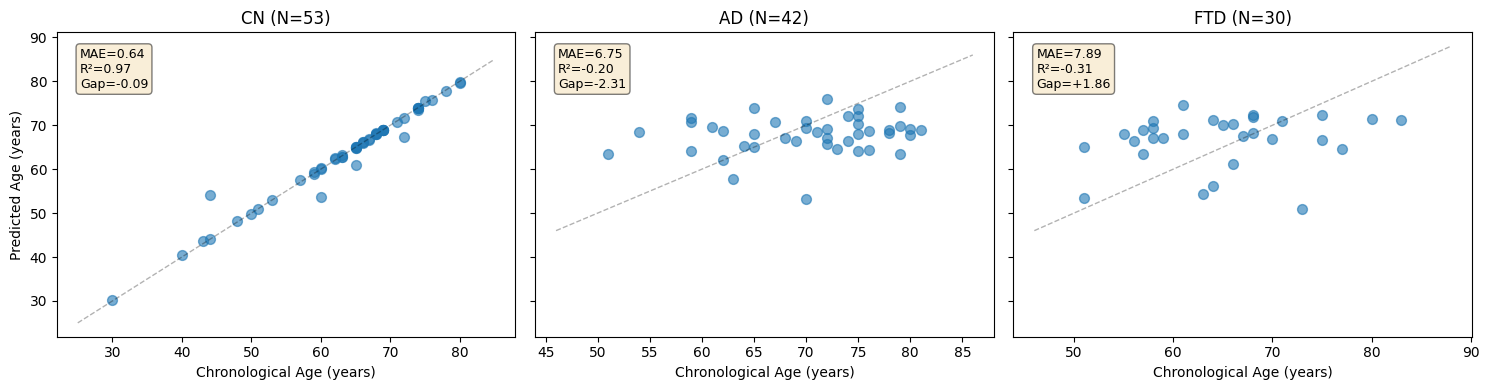

In [28]:
# Plot scatter for each diagnosis
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, diag in enumerate(["CN", "AD", "FTD"]):
    sub_df = test_df[test_df["diagnosis"] == diag]
    if len(sub_df) == 0:
        continue
    
    ax = axes[i]
    ax.scatter(sub_df["y_true"], sub_df["y_pred"], alpha=0.6, s=50)
    
    # Identity line
    lims = [sub_df["y_true"].min()-5, sub_df["y_true"].max()+5]
    ax.plot(lims, lims, 'k--', alpha=0.3, lw=1)
    
    metrics_diag = regression_metrics(sub_df["y_true"].values, sub_df["y_pred"].values)
    gap = sub_df["brain_age_gap"].mean()
    
    ax.set_title(f"{diag} (N={len(sub_df)})")
    ax.set_xlabel("Chronological Age (years)")
    if i == 0:
        ax.set_ylabel("Predicted Age (years)")
    
    # Add metrics text
    textstr = f"MAE={metrics_diag['MAE']:.2f}\nR²={metrics_diag['R2']:.2f}\nGap={gap:+.2f}"
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
fig_path = EXP_DIR / "exp2_cn_only_scatter.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"\nFigure saved: {fig_path}")
plt.show()

---

## Experimento 3: FC crudo + T1w (sin VAE)

**Hipótesis:** Si XGBoost recibe los 6670 features crudos de FC (triángulo superior de la matriz 116×116) concatenados con los 116 features de T1w (total: 6786 features), es probable que su rendimiento sea inferior al pipeline con VAE (64 + 116 = 180 features), ya que la alta dimensionalidad con pocos sujetos de entrenamiento (~1120) favorece el sobreajuste.

**Objetivo:** Justificar la necesidad de la compresión no lineal del VAE como paso de reducción de dimensionalidad.

**Metodología:** Cada configuración usa hiperparámetros de XGBoost optimizados **independientemente** con Optuna. Los parámetros para raw FC fueron optimizados en `optuna_raw_fc.ipynb` (50 trials, 5-fold CV). Esto garantiza una comparación justa.

In [29]:
# Raw FC XGBoost params (optimized in optuna_raw_fc.ipynb — 50 trials, 5-fold CV)
raw_fc_xgb_params = {
    "n_estimators": 458,
    "max_depth": 3,
    "learning_rate": 0.03530771088566478,
    "subsample": 0.9559350035129378,
    "colsample_bytree": 0.10442179408200097,
    "reg_alpha": 0.07562391855194042,
    "reg_lambda": 0.19912112625989395,
    "min_child_weight": 10.287060507653141,
    "gamma": 2.493016501874793,
    "tree_method": "hist",
    "random_state": 42,
    "eval_metric": "mae",
    "n_jobs": -1,
}

# Load VAE+T1w baseline from main pipeline's ablation results (independent of Exp 1)
abl_path = paths.out_dir / "metrics" / "ablation_results.json"
with open(abl_path) as f:
    metrics_vae_baseline = json.load(f)["VAE(Z) + T1w"]

# Build features with raw FC (6670) + T1w (116) = 6786 features total
X_raw_tr = build_feats(Z=X_trainval, T1=T1_tr)
X_raw_te = build_feats(Z=X_test, T1=T1_te)

print(f"Raw FC + T1w features — train: {X_raw_tr.shape}, test: {X_raw_te.shape}")

# Clean
X_raw_tr_clean, y_raw_tr_clean = clean_xy(X_raw_tr, y_tr)
X_raw_te_clean, y_raw_te_clean = clean_xy(X_raw_te, y_te)

# Train XGBoost with params optimized for raw FC (from optuna_raw_fc.ipynb)
model_raw = train_xgb(X_raw_tr_clean, y_raw_tr_clean, raw_fc_xgb_params)
y_pred_raw = model_raw.predict(X_raw_te_clean)
metrics_raw = regression_metrics(y_raw_te_clean, y_pred_raw)

print("\n=== Raw FC (6670) + T1w Results (Optuna-optimized for raw FC) ===")
print(f"MAE:     {metrics_raw['MAE']:.2f} years")
print(f"RMSE:    {metrics_raw['RMSE']:.2f} years")
print(f"R²:      {metrics_raw['R2']:.3f}")
print(f"Pearson: {metrics_raw['Pearson']:.3f}")

# Comparison: each method with its own Optuna-optimized XGBoost params
print("\n" + "=" * 75)
print("EXPERIMENT 3: Raw FC + T1w vs VAE + T1w (each Optuna-optimized)")
print("=" * 75)
print(f"{'Method':<30} | {'Features':>8} | {'MAE':>6} | {'RMSE':>6} | {'R²':>6} | {'Pearson':>7}")
print("-" * 75)
print(f"{'Raw FC + T1w (own Optuna)':<30} | {X_raw_tr.shape[1]:>8} | {metrics_raw['MAE']:6.2f} | {metrics_raw['RMSE']:6.2f} | {metrics_raw['R2']:6.3f} | {metrics_raw['Pearson']:7.3f}")
print(f"{'VAE + T1w (own Optuna)':<30} | {180:>8} | {metrics_vae_baseline['MAE']:6.2f} | {metrics_vae_baseline['RMSE']:6.2f} | {metrics_vae_baseline['R2']:6.3f} | {metrics_vae_baseline['Pearson']:7.3f}")
print("-" * 75)
mae_diff = metrics_raw['MAE'] - metrics_vae_baseline['MAE']
r2_diff = metrics_vae_baseline['R2'] - metrics_raw['R2']
print(f"VAE advantage:  {mae_diff:+.2f} years MAE,  {r2_diff:+.3f} R²")
print(f"Feature reduction: {X_raw_tr.shape[1]} → 180 ({(1 - 180/X_raw_tr.shape[1])*100:.1f}% reduction)")
print("=" * 75)

# Save results
exp3_results = {
    "raw_fc_t1w": metrics_raw,
    "vae_t1w": metrics_vae_baseline,
    "vae_advantage": {
        "mae_diff": float(mae_diff),
        "r2_diff": float(r2_diff),
    },
    "raw_n_features": int(X_raw_tr.shape[1]),
    "vae_n_features": 180,
}

exp3_path = EXP_DIR / "exp3_raw_fc_vs_vae.json"
with open(exp3_path, "w") as f:
    json.dump(exp3_results, f, indent=2)

print(f"\nResults saved: {exp3_path}")

Raw FC + T1w features — train: (1120, 6786), test: (125, 6786)

=== Raw FC (6670) + T1w Results (Optuna-optimized for raw FC) ===
MAE:     6.00 years
RMSE:    7.55 years
R²:      0.354
Pearson: 0.601

EXPERIMENT 3: Raw FC + T1w vs VAE + T1w (each Optuna-optimized)
Method                         | Features |    MAE |   RMSE |     R² | Pearson
---------------------------------------------------------------------------
Raw FC + T1w (own Optuna)      |     6786 |   6.00 |   7.55 |  0.354 |   0.601
VAE + T1w (own Optuna)         |      180 |   5.62 |   7.20 |  0.411 |   0.644
---------------------------------------------------------------------------
VAE advantage:  +0.38 years MAE,  +0.058 R²
Feature reduction: 6786 → 180 (97.3% reduction)

Results saved: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/exp3_raw_fc_vs_vae.json


---

## Resumen de Experimentos

### Experimento 1: PCA vs VAE
**Estado:** Completado

**Resultado:** PCA (MAE=5.61, R²=0.431) y VAE (MAE=5.62, R²=0.411) alcanzan rendimiento prácticamente idéntico con XGBoost optimizado. Las diferencias son < 0.02 en todas las métricas. Esto sugiere que la información relevante para la predicción de edad es capturada por las componentes principales, y que un regresor potente extrae patrones no lineales aun desde features linealmente proyectados.

---

### Experimento 2: CN-Only Training
**Estado:** Completado

**Resultado:**
- CN test (N=53): MAE=0.64, gap=-0.09 años (sobreajuste severo al grupo de entrenamiento)
- AD test (N=42): MAE=6.75, gap=-2.31 años (resultado inesperado, posible confusión atrofia/edad)
- FTD test (N=30): MAE=7.89, gap=+1.86 años (envejecimiento acelerado, como se esperaba)

---

### Experimento 3: Raw FC + T1w vs VAE + T1w
**Estado:** Completado

**Resultado (Optuna-optimizado independientemente, params de `optuna_raw_fc.ipynb`):**
- Raw FC + T1w (6786 features): MAE=6.00, R²=0.354 (con params optimizados para 6786 features).
- VAE + T1w (180 features): MAE=5.62, R²=0.411 (con params optimizados para 180 features).
- **La reducción de dimensionalidad mejora en 0.38 años MAE y +16% R² relativo.**
- La clave es comprimir 6670 → 64 dimensiones (97.3% reducción), no si la compresión es lineal o no lineal.

---

Los resultados se encuentran en `Outputs/experiments/`.